# [LAB-10] 4-1. 혼동행렬의 이해

## #01. 준비작업

### 1. 패키지 참조

In [1]:
# 라이브러리 기본 참조
from jussam import load_data
from helpers import *
from pandas import DataFrame

import numpy as np

# 분류 성능 평가를 위한 참조
from sklearn.metrics import confusion_matrix

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

직전 단원과 동일한 데이터에 대해 전처리가 완료된 데이터를 준비한다.

In [2]:
origin = load_data('pima_indians_diabetes_preprocessed')
origin.head()

📚 피마 인디언 당뇨병 데이터셋에 대한 전처리 버전 - 결측치 처리, 이상치 처리, 라벨링 (출처: 자체 작업)


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.000,72.000,33.600,0.627,50,1
1,1,85.000,66.000,26.600,0.351,31,0
2,8,183.000,64.000,23.300,0.672,32,1
3,1,89.000,66.000,28.100,0.167,21,0
4,0,137.000,40.000,43.100,2.288,33,1


### 3. 로지스틱 회귀 모델 적합

In [3]:
fit = my_logit.auto_logit(origin, 'Outcome', plot=False)

#### ▶︎ 모형 적합도

**Note. n = 724. LL = -336.431, LL-Null = -465.969, LLR χ²(6) = 259.076, p < 0.001, Pseudo R² = 0.278**

Outcome를 종속변수로, Pregnancies, Glucose, BloodPressure, BMI, DiabetesPedigreeFunction, Age(을)를 독립변수로 한 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(6) = 259.076, p < 0.001, Pseudo R² = 0.278.

즉, 모형의 유사결정계수는 0.278로 매우 우수한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

#### ▶︎ 독립변수 보고

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.961,0.319,0.306,3.135,0.002,2.613,1.433,4.764,0.959,1.043
1,Outcome,Pregnancies,0.118,0.396,0.033,3.527,0.000,1.125,1.054,1.201,0.687,1.455
2,Outcome,BMI,0.091,0.626,0.016,5.777,0.000,1.095,1.062,1.130,0.860,1.162
3,Outcome,Glucose,0.035,1.082,0.004,9.763,0.000,1.036,1.029,1.043,0.865,1.156
4,Outcome,Age,0.017,0.199,0.010,1.723,0.085,1.017,0.998,1.037,0.615,1.626
5,Outcome,BloodPressure,-0.009,-0.110,0.009,-1.035,0.301,0.991,0.975,1.008,0.804,1.243


- **Pregnancies**의 회귀계수는 **B = 0.1179**, 오즈비는 **OR = 1.1251**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다.      
(**z = 3.53**, **p < .001**)      
즉, **Pregnancies**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **12.5% 증가**하는 것으로 해석된다.
- **Glucose**의 회귀계수는 **B = 0.0352**, 오즈비는 **OR = 1.0358**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다.      
(**z = 9.76**, **p < .001**)      
즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.6% 증가**하는 것으로 해석된다.
- **BloodPressure**의 회귀계수는 **B = -0.0089**, 오즈비는 **OR = 0.9911**로 나타났으며, 이는 **Outcome**에 유의하지 않은 요인임을 의미한다.      
(**z = -1.03**, **p = .301**)      
즉, **BloodPressure**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **0.9% 감소**하는 것으로 해석된다.
- **BMI**의 회귀계수는 **B = 0.0909**, 오즈비는 **OR = 1.0952**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다.      
(**z = 5.78**, **p < .001**)      
즉, **BMI**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **9.5% 증가**하는 것으로 해석된다.
- **DiabetesPedigreeFunction**의 회귀계수는 **B = 0.9605**, 오즈비는 **OR = 2.613**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다.      
(**z = 3.13**, **p = .002**)      
즉, **DiabetesPedigreeFunction**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **161.3% 증가**하는 것으로 해석된다.
- **Age**의 회귀계수는 **B = 0.0169**, 오즈비는 **OR = 1.0171**로 나타났으며, 이는 **Outcome**에 유의하지 않은 요인임을 의미한다.      
(**z = 1.72**, **p = .085**)      
즉, **Age**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **1.7% 증가**하는 것으로 해석된다.

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다.

## #02. 혼동행렬(Confusion Matrix)

### 1. 혼동행렬 구성 1단계 - 실제 정답 꺼내기

- 적합된 모형 객체 안에는 학습에 사용한 **실제 종속변수 값**이 들어 있다.

In [4]:
# 실제 당뇨 여부(0/1)
y_true = np.asarray(fit.model.endog).astype(int)

# 상위 20개만 출력
y_true[:20]

array([1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1])

### 2. 혼동행렬 구성 2단계 - 모형이 예측한 확률 꺼내기

- 로지스틱 회귀의 예측값은 0이나 1이 아니라 "당뇨일 확률(0~1 사이의 값)"이다.
- 그래서 곧바로 정답(종속변수 --> 0 혹은 1)과 비교할 수 없다.

In [5]:
# 각 사람이 당뇨(1)일 예측 확률
proba = np.asarray(fit.predict())

# 상위 20개만 소수점 3자리로 반올림하여 출력
proba[:20].round(3)

array([0.693, 0.041, 0.761, 0.038, 0.898, 0.128, 0.057, 0.803, 0.209,
       0.883, 0.77 , 0.801, 0.646, 0.416, 0.172, 0.307, 0.227, 0.437,
       0.3  , 0.937])

### 3. 혼동행렬 구성 3단계 - 확률을 0/1로 자르기

- 확률을 범주로 바꾸려면 **자르는 기준(임계값, threshold)** 이 필요하다.
  - 관례적으로 **0.5** 를 쓴다. 즉 **50%를 넘으면 당뇨(1)** 로 본다.
  - 임계값은 정해진 값이 아니라 **분석자가 고르는 값**이다. (#04에서 바꿔 본다)

In [6]:
# 임계값 0.5로 이진화
y_pred = (proba > 0.5).astype(int)

# 상위 20개만 출력
y_pred[:20]

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1])

### 4. 현재 모형의 혼동행렬

- `statsmodels`만으로 이 네 칸을 구하기는 번거롭다. 머신러닝 라이브러리인 `sklearn`의 함수를 미리 빌려 쓴다.
- 실제값과 예측 범주를 `confusion_matrix()`에 넣으면 2×2 표가 나온다.

In [7]:
cm = confusion_matrix(y_true, y_pred)

cmdf = DataFrame(cm,
            index=["실제 0 (정상)", "실제 1 (당뇨)"],
            columns=["예측 0 (정상)", "예측 1 (당뇨)"])
cmdf

,예측 0 (정상),예측 1 (당뇨)
실제 0 (정상),420,55
실제 1 (당뇨),107,142


### 5. 각 지표를 개별 추출하기

In [8]:
# 네 칸을 TN / FP / FN / TP 로 분해 (순서가 정해져 있다)
tn, fp, fn, tp = cm.ravel()

print(f"TN(정상인을 정상으로 맞힘) : {tn}")
print(f"FP(정상인을 당뇨로 헛짚음) : {fp}")
print(f"FN(당뇨 환자를 놓침)       : {fn}")
print(f"TP(당뇨 환자를 맞힘)       : {tp}")

TN(정상인을 정상으로 맞힘) : 420
FP(정상인을 당뇨로 헛짚음) : 55
FN(당뇨 환자를 놓침)       : 107
TP(당뇨 환자를 맞힘)       : 142


#### 인사이트

- 맞힌 것은 대각선 **TN 420 + TP 142 = 562명**이다. 3단원 끝에서 물었던 *"724명 중 몇 명?"* 의 답이 나왔다.
- 하지만 더 중요한 것은 **틀린 162명**이다. 뜯어보면 성격이 완전히 다르다.
  - **헛짚음(FP) 55명** — 정상인데 당뇨로 판정
  - **놓침(FN) 107명** — 당뇨인데 정상으로 판정
- **놓친 사람이 헛짚은 사람의 두 배**다. 당뇨 환자 249명 중 107명을 그냥 지나쳤다는 뜻이다.
- 이렇게 **틀림을 두 종류로 나눠 두었기 때문에**, 다음 장에서 서로 다른 질문에 답하는 지표들을 만들어 낼 수 있다.

### 4. 혼동행렬 히트맵

- 숫자 표보다 **색의 진하기**로 보면 어느 칸이 큰지 한눈에 들어온다.

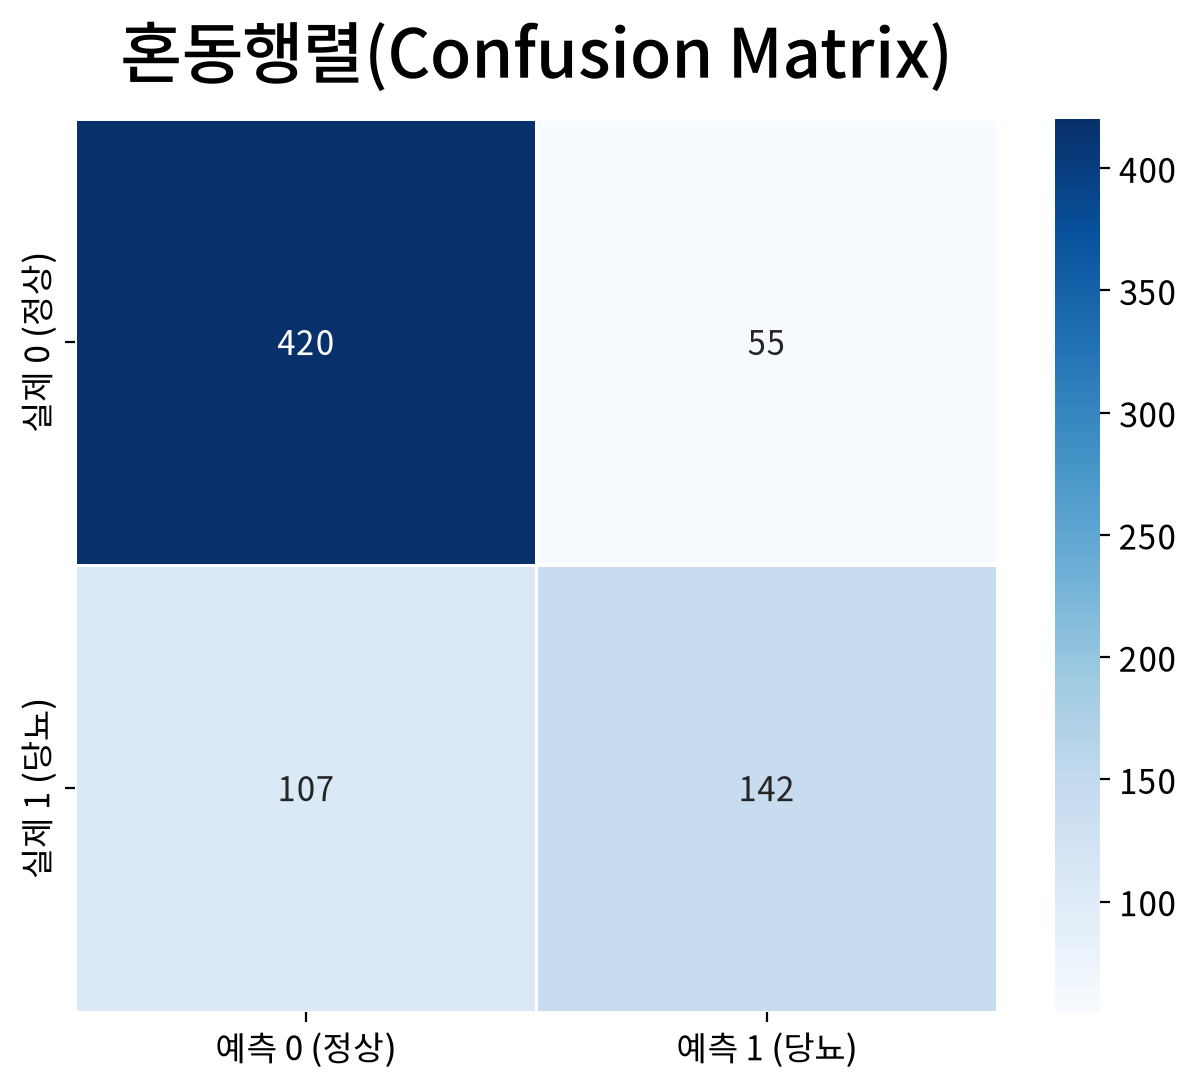

In [9]:
my_plot.heatmap(data=cmdf, annot=True, fmt="d", palette="Blues",
        title="혼동행렬(Confusion Matrix)", width=640, height=560)